<a href="https://colab.research.google.com/github/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Agrupamiento_textos_LB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasificación de texto**

**Nombre:** Laila Montserrat Bulhosen Ramos **Matrícula**: 263166

**Docente:** Dr. Rogelio Florencia Juarez

**Materia:** Procesamiento de Lenguaje Natural



**Link Github:** [Agrupamiento_texto_LB](https://github.com/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Agrupamiento_textos_LB.ipynb)

**Fecha:** Mayor 2026


### **1. Carga de datos**

In [2]:
from sklearn.datasets import fetch_20newsgroups
dataset = fetch_20newsgroups(subset = 'all', remove = ('headers','footers','quotes'))
docs_raw = dataset.data

In [8]:
### Vista previa
print(docs_raw[0])



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!




### **1.1 Preprocesamiento de datos**

Conversión a minúsculas

In [13]:
docs_min = [doc.lower() for doc in docs_raw]

### Verificación de los cambios a minúsculas
print(docs_min[0])



i am sure some bashers of pens fans are pretty confused about the lack
of any kind of posts about the recent pens massacre of the devils. actually,
i am  bit puzzled too and a bit relieved. however, i am going to put an end
to non-pittsburghers' relief with a bit of praise for the pens. man, they
are killing those devils worse than i thought. jagr just showed you why
he is much better than his regular season stats. he is also a lot
fo fun to watch in the playoffs. bowman should let jagr have a lot of
fun in the next couple of games since the pens are going to beat the pulp out of jersey anyway. i was very disappointed not to see the islanders lose the final
regular season game.          pens rule!!!




Eliminación de puntuaciones

In [14]:
import re

In [16]:
docs_clean = [re.sub(r'[^\w\s]', '', doc) for doc in docs_min]

### Verificación de remover puntuaciones
print(docs_clean[0])



i am sure some bashers of pens fans are pretty confused about the lack
of any kind of posts about the recent pens massacre of the devils actually
i am  bit puzzled too and a bit relieved however i am going to put an end
to nonpittsburghers relief with a bit of praise for the pens man they
are killing those devils worse than i thought jagr just showed you why
he is much better than his regular season stats he is also a lot
fo fun to watch in the playoffs bowman should let jagr have a lot of
fun in the next couple of games since the pens are going to beat the pulp out of jersey anyway i was very disappointed not to see the islanders lose the final
regular season game          pens rule




Eliminación de stopwords en inglés y tokenización

In [22]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [28]:
nltk.download('stopwords')
nltk.download('punkt')
english_stopwords = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [30]:
nltk.download('punkt_tab') # Download the punkt_tab tokenizer model


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [65]:
stopwords_eng = stopwords.words('english')

all_tokens = [word_tokenize(doc, language='english') for doc in docs_clean]

### Verificacion de tokens para el primer record
print(all_tokens[0][0:10])

['i', 'am', 'sure', 'some', 'bashers', 'of', 'pens', 'fans', 'are', 'pretty']


### **2 Entrenamiento de embeddings**

#### **2.1 Entrenamiento de embeddings con Word2Vec**

In [42]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.0 MB/s eta 0:00:00


In [43]:

from gensim.models import Word2Vec
from sklearn.cluster import KMeans

In [45]:
### Entrenar con vectores de tamaño 100

model = Word2Vec(
    sentences = all_tokens,
    vector_size = 100,
    window = 5,
    min_count = 3,
    workers = 4,
    sg = 1
)

model.train(all_tokens, total_examples=len(all_tokens), epochs=10)

(25532296, 33621110)

In [46]:
embeddings = model.wv.vectors
k = 6

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(embeddings)

labels = kmeans.labels_

#### **2.2 Determinar valor de K**

##### Método del codo

In [48]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

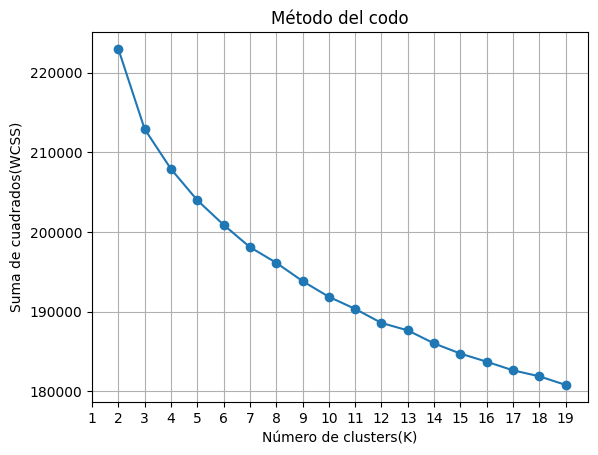

In [58]:
wcss = []
K = range(2, 20)

for k in K:
  kmeans = KMeans(n_clusters = k)
  kmeans.fit(embeddings)
  wcss.append(kmeans.inertia_)

plt.plot(K, wcss, marker = 'o')

plt.xlabel('Número de clusters(K)')
plt.xticks(np.arange(1, 20, 1))
plt.ylabel('Suma de cuadrados(WCSS)')
plt.title('Método del codo')

plt.grid(True)
plt.show()



Aplicando el método el codo el mejor valor de K parece estar en 12

##### Coeficiente de Silhoutte

In [59]:
from sklearn.metrics import silhouette_score


In [97]:
sil_scores = []

for k in K:
  kmeans = KMeans(n_clusters = k)
  labels = kmeans.fit_predict(embeddings)

  score = silhouette_score(embeddings, labels)
  sil_scores.append(score)

  print(f'K = {k}, Silhoutte = {round(score, 3)}')


K = 2, Silhoutte = 0.07800000160932541
K = 3, Silhoutte = 0.0729999989271164
K = 4, Silhoutte = 0.05700000002980232
K = 5, Silhoutte = 0.050999999046325684
K = 6, Silhoutte = 0.04800000041723251
K = 7, Silhoutte = 0.04500000178813934
K = 8, Silhoutte = 0.04500000178813934
K = 9, Silhoutte = 0.04500000178813934
K = 10, Silhoutte = 0.039000000804662704
K = 11, Silhoutte = 0.035999998450279236
K = 12, Silhoutte = 0.017999999225139618
K = 13, Silhoutte = 0.02500000037252903
K = 14, Silhoutte = 0.023000000044703484
K = 15, Silhoutte = -0.008999999612569809
K = 16, Silhoutte = 0.024000000208616257
K = 17, Silhoutte = 0.017999999225139618
K = 18, Silhoutte = 0.014000000432133675
K = 19, Silhoutte = -0.017000000923871994


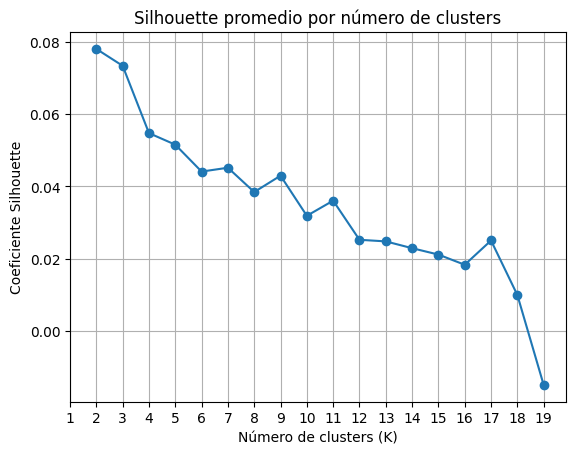

In [67]:
plt.plot(K, sil_scores, marker = 'o')

plt.xlabel('Número de clusters (K)')
plt.xticks(np.arange(1, 20, 1))
plt.ylabel('Coeficiente Silhouette')
plt.title('Silhouette promedio por número de clusters')

plt.grid(True)
plt.show()

Deacuerdo al coeficiente de Silhoutte muestra que el mejor numero de clusters es en K = 2  a partir de K=3 en adelante la calidad de los clusters se degrada progresivamente.



#### **2.3 Entrenamiento de K-Means con K óptimo**

In [68]:
k = 2

kmeans = KMeans(n_clusters=k, random_state=42)
labels =kmeans.fit_predict(embeddings)

#### **2.4 Entrenamiento K-Means usando K óptimo**

##### 2.4.1 Cálculo de métrica de Silhoutte

In [69]:
silhouette = silhouette_score(embeddings, labels)

print(f'Silhouette Score: {silhouette}')

Silhouette Score: 0.07802310585975647


##### 2.4.2 Cálculo de métrica Davies-Bouldin Index (DB)

In [70]:
from sklearn.metrics import davies_bouldin_score

In [71]:
db_index = davies_bouldin_score(embeddings, labels)

print(f'Davies–Bouldin Index: {db_index}')

Davies–Bouldin Index: 3.1533589651318064


##### 2.4.3 Cálculo de métrica Calinski–Harabasz (CH)

In [72]:
from sklearn.metrics import calinski_harabasz_score


In [73]:
ch_index = calinski_harabasz_score(embeddings, labels)

print(f'Calinski–Harabasz Index: {ch_index}')

Calinski–Harabasz Index: 2860.885986328125


### **3 Clustering con DBSCAN**



In [81]:
from sklearn.cluster import DBSCAN
import pandas as pd

In [77]:
### Configuración de DBSCAN
### El rango inicial pa min_samples suele estar entre 0.1 y 5.0 , se elige incrementos 0.5
### Para eps se recomienda un rango de valores entre 4 y 10, se elige valores de 4 a 7

eps_list = [0.5, 1, 1.5, 2]
min_samples_list = [4, 5, 6, 7]

resultados = []

for eps_value in eps_list:
  for min_samples_values in min_samples_list:
    ### Correr modelo
    dbscan = DBSCAN(
    eps = eps_value
    ,min_samples = min_samples_values
    ,metric = 'euclidean'
    )

    labels = dbscan.fit_predict(embeddings)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f'Número de clusters: {n_clusters}')
    print(f'Número de puntos de ruido: {n_noise}')

    ### Cálculo de métricas Silhoutte, Davies-Bouldin, Calinski-Harabasz

    silhouette = silhouette_score(embeddings, labels)

    db_index = davies_bouldin_score(embeddings, labels)

    ch_index = calinski_harabasz_score(embeddings, labels)


    iteration_result = {'eps_val': eps_value, 'min_samples_val': min_samples_values, 'Silhoute_val' : silhouette, 'DB_val': db_index, 'CH_val': ch_index}

    resultados.append(iteration_result)



Número de clusters: 27
Número de puntos de ruido: 39875
Número de clusters: 19
Número de puntos de ruido: 39937
Número de clusters: 16
Número de puntos de ruido: 39972
Número de clusters: 11
Número de puntos de ruido: 40031
Número de clusters: 95
Número de puntos de ruido: 37705
Número de clusters: 50
Número de puntos de ruido: 37971
Número de clusters: 41
Número de puntos de ruido: 38107
Número de clusters: 31
Número de puntos de ruido: 38253
Número de clusters: 16
Número de puntos de ruido: 21268
Número de clusters: 7
Número de puntos de ruido: 21410
Número de clusters: 6
Número de puntos de ruido: 21478
Número de clusters: 4
Número de puntos de ruido: 21537
Número de clusters: 5
Número de puntos de ruido: 12827
Número de clusters: 1
Número de puntos de ruido: 12866
Número de clusters: 1
Número de puntos de ruido: 12883
Número de clusters: 1
Número de puntos de ruido: 12895


In [80]:
resultados_df = pd.DataFrame(resultados)

resultados_df

,eps_val,min_samples_val,Silhoute_val,DB_val,CH_val
0,0.5,4,-0.155618,1.303092,11.238929
1,0.5,5,-0.150313,1.307531,13.391243
2,0.5,6,-0.149704,1.493848,14.108583
3,0.5,7,-0.126813,1.732865,15.807470
4,1.0,4,-0.329664,1.716021,11.954452
5,1.0,5,-0.318154,1.970509,22.539518
6,1.0,6,-0.315787,2.066767,26.391106
7,1.0,7,-0.305863,2.138889,33.581348
8,1.5,4,-0.099207,2.270907,38.266937
9,1.5,5,-0.063863,3.240695,81.031570


##### 3.1 Conclusiones

El mejor resultado para el modelo DB fue el obtenido con eps = 0.5 y min_samples = 4 se obtuvo un valor de 1.303092

Los mejores resultados para Silhoutte y CH se obtuvieron con un eps = 2 y min_saples = 5, los mejores resultados obtenidos respectivamente fueron 0.144371 y  460.845917. Con esto se puede decir que Silhoutte y CH tuvieron el mejor resultado.

### **4. Visualizaciones**

##### 4.1	PCA o tSNE en 2D mostrando los clusters de K-Means

In [84]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

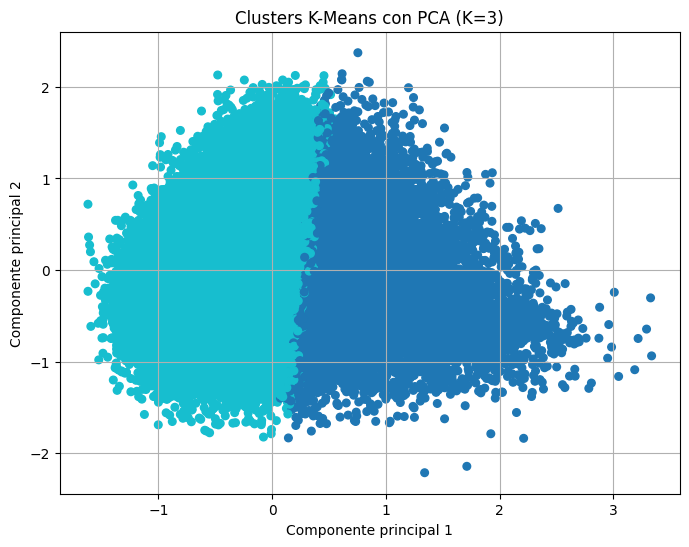

In [99]:
### Ajustar K-Means
### Se considera cluster = 2 al ser el valor obtenido en pasos anteriores

kmeans = KMeans(n_clusters = 2, random_state=42)
dbscan = DBSCAN(eps=0.5, min_samples=4, metric='euclidean')
labels_kmeans = kmeans.fit_predict(embeddings)

### Reducir a 2 dimensiones con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(embeddings)

### Graficar clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans, cmap='tab10', s=30)

plt.title('Clusters K-Means con PCA (K=3)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')

plt.grid(True)
plt.show()

##### 4.2	PCA o tSNE en 2D mostrando los clusters de DBSCAN

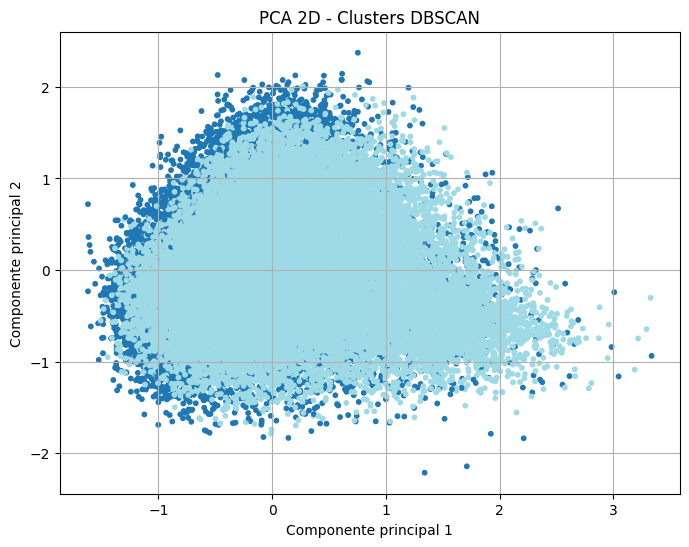

In [100]:
# Ajustar DBSCAN con los mejores parametros
dbscan = DBSCAN(
    eps = 2 ,
    min_samples = 5,
    metric='euclidean'
)

labels_dbscan = dbscan.fit_predict(embeddings)

### Reducir a 2 dimensiones con PCA
pca = PCA(n_components=2)
reduced_pca = pca.fit_transform(embeddings)

### Graficar clusters en espacio PCA

plt.figure(figsize=(8,6))
plt.scatter(reduced_pca[:,0], reduced_pca[:,1],
            c=labels_dbscan, cmap='tab20', s=10)
plt.title("PCA 2D - Clusters DBSCAN")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()

##### 4.3 Nube de palabras

In [104]:
from wordcloud import WordCloud

In [105]:

def generar_nubes(labels, docs, modelo):
    for cluster_id in set(labels):
        if cluster_id == -1:
            continue
        cluster_docs = [docs[i] for i in range(len(docs)) if labels[i] == cluster_id]
        text_cluster = " ".join(cluster_docs)

        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='plasma',
            max_words=100
        ).generate(text_cluster)

        plt.figure(figsize=(10,5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Nube de palabras - {modelo} Cluster {cluster_id}")
        plt.show()


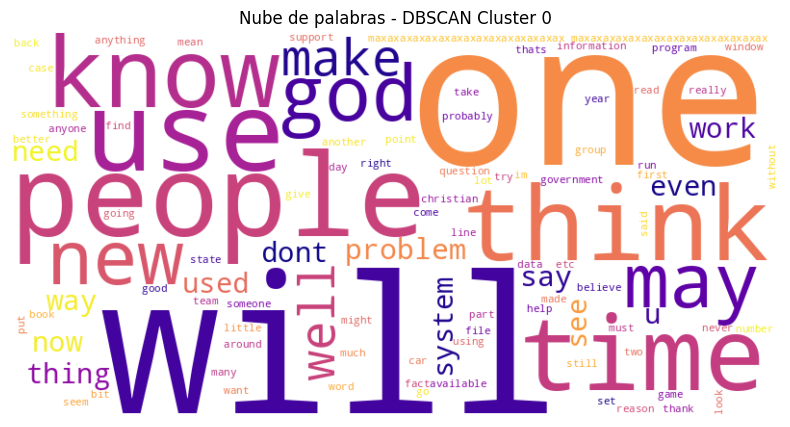

In [108]:
### Generar nubes para DBSCAN

generar_nubes(labels_dbscan, docs_clean, 'DBSCAN')


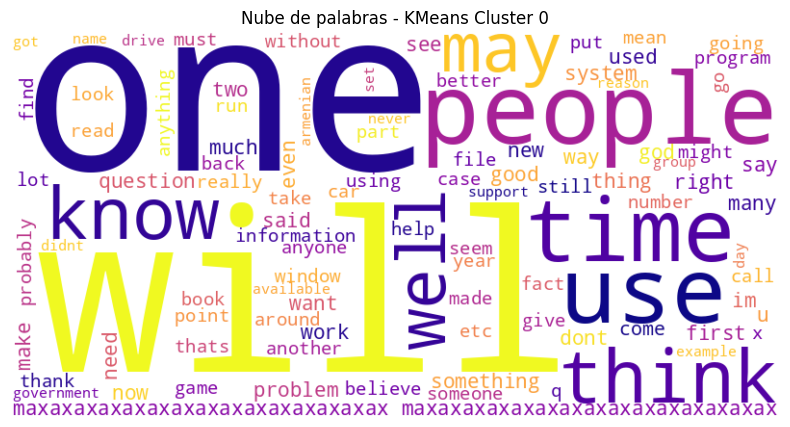

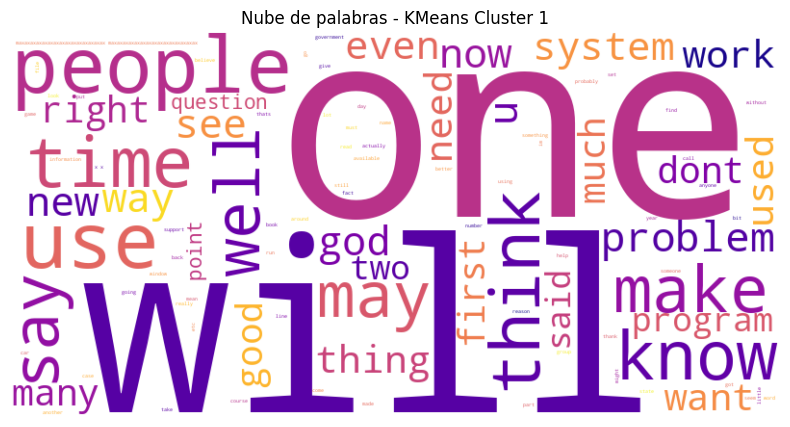

In [109]:
# Generar nubes para KMeans
generar_nubes(labels_kmeans, docs_clean, "KMeans")
